# Inspect tSNR

Group-level and per-subject temporal SNR from fMRIPrep MNI-space BOLD
(`fmriprep-24.0.1-noSDC`). Computed as `mean(signal) / std(linearly-detrended signal)`
per run, averaged across runs per subject, then across subjects for the group map.

Sections:
1. Spatial distribution — axial and coronal views to identify dropout regions
2. ROI comparison — group mean tSNR for PFC and reference regions
3. Per-subject distributions — variability across subjects and outlier flagging


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import image, plotting
from nilearn.datasets import fetch_atlas_harvard_oxford

TSNR_DIR = "/Users/hugofluhr/phd_local/data/LearningHabits/tsnr_fmriprep"


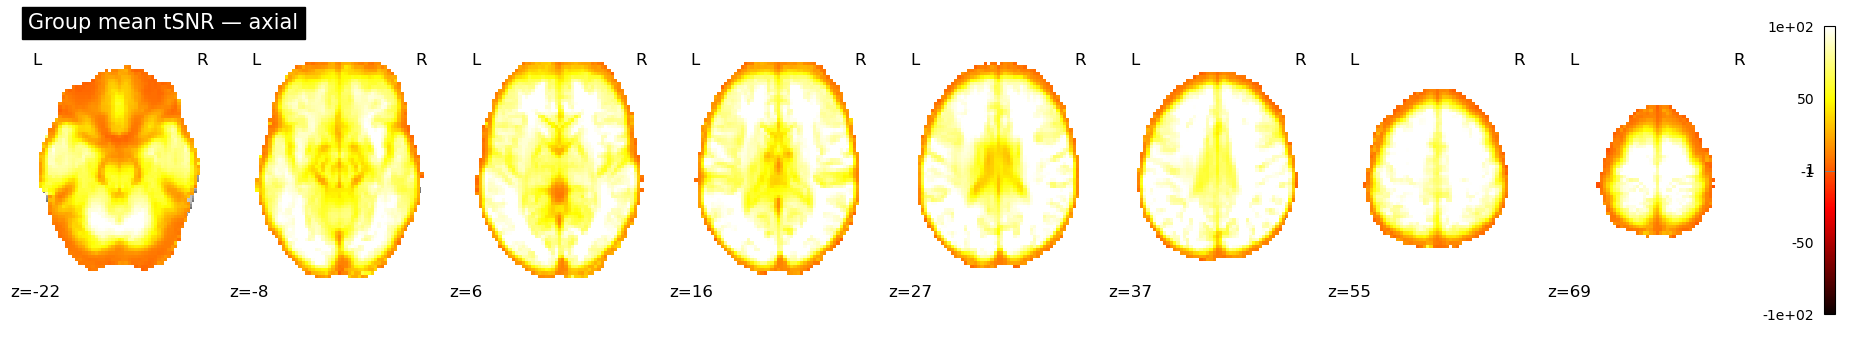

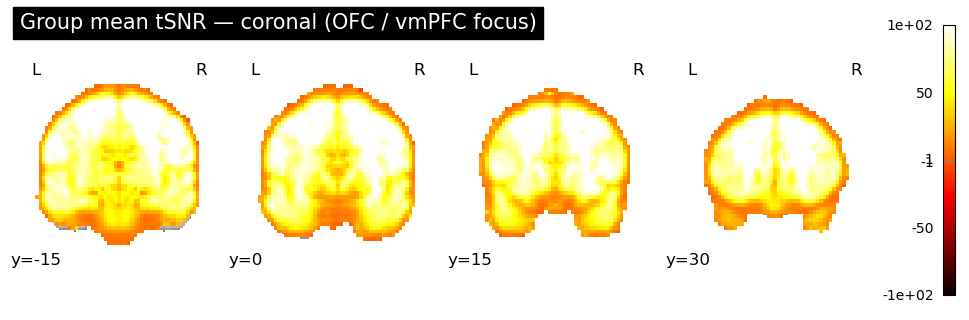

In [2]:
group_tsnr = nib.load(os.path.join(TSNR_DIR, "group_mean_tsnr.nii.gz"))

# Axial: full-brain overview
plotting.plot_stat_map(
    group_tsnr,
    display_mode='z', cut_coords=8,
    colorbar=True, cmap='hot',
    title='Group mean tSNR — axial',
    threshold=1, vmax=100,
)
plt.show()

# Coronal: captures OFC / vmPFC signal dropout
plotting.plot_stat_map(
    group_tsnr,
    display_mode='y', cut_coords=[-15, 0, 15, 30],
    colorbar=True, cmap='hot',
    title='Group mean tSNR — coronal (OFC / vmPFC focus)',
    threshold=1, vmax=100,
)
plt.show()


[fetch_atlas_harvard_oxford] Dataset found in /Users/hugofluhr/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /Users/hugofluhr/nilearn_data/fsl


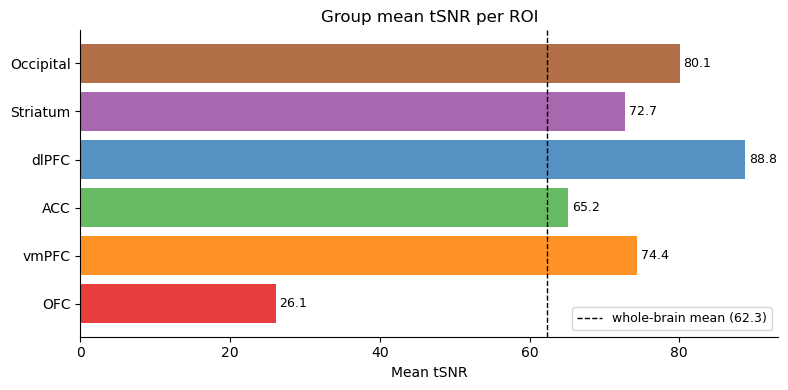

In [3]:
PROB_THRESH = 25

ho_cort = fetch_atlas_harvard_oxford('cort-prob-2mm')
ho_sub  = fetch_atlas_harvard_oxford('sub-prob-2mm')
cort_4d = image.load_img(ho_cort.maps)
sub_4d  = image.load_img(ho_sub.maps)


def make_roi(atlas_4d, labels, name_fragments):
    data    = atlas_4d.get_fdata()
    indices = [i for i, l in enumerate(labels)
               if any(f.lower() in l.lower() for f in name_fragments)]
    if not indices:
        raise ValueError(f"No match: {name_fragments}")
    combined = data[..., indices].max(axis=-1)
    return image.new_img_like(atlas_4d, (combined >= PROB_THRESH).astype(np.int8))


rois = {
    "OFC":       make_roi(cort_4d, ho_cort.labels, ["Frontal Orbital Cortex"]),
    "vmPFC":     make_roi(cort_4d, ho_cort.labels, ["Frontal Medial Cortex", "Paracingulate Gyrus"]),
    "ACC":       make_roi(cort_4d, ho_cort.labels, ["Cingulate Gyrus, anterior"]),
    "dlPFC":     make_roi(cort_4d, ho_cort.labels, ["Middle Frontal Gyrus", "Superior Frontal Gyrus"]),
    "Striatum":  make_roi(sub_4d,  ho_sub.labels,  ["Caudate", "Putamen"]),
    "Occipital": make_roi(cort_4d, ho_cort.labels, ["Lateral Occipital"]),
}
PFC_ROIS = ["OFC", "vmPFC", "ACC", "dlPFC"]
REF_ROIS = ["Striatum", "Occipital"]
colors   = {"OFC": "#e41a1c", "vmPFC": "#ff7f00", "ACC": "#4daf4a",
            "dlPFC": "#377eb8", "Striatum": "#984ea3", "Occipital": "#a65628"}

# Resample ROIs to tSNR map space; exclude zeros (out-of-mask voxels)
tsnr_data = group_tsnr.get_fdata()
roi_means = {}
for name, roi_img in rois.items():
    roi_res = image.resample_to_img(roi_img, group_tsnr, interpolation='nearest')
    mask    = (roi_res.get_fdata() > 0) & (tsnr_data > 0)
    roi_means[name] = tsnr_data[mask].mean()

roi_order = PFC_ROIS + REF_ROIS
means     = [roi_means[r] for r in roi_order]
wb_mean   = tsnr_data[tsnr_data > 0].mean()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(roi_order, means, color=[colors[r] for r in roi_order], alpha=0.85)
ax.axvline(wb_mean, color='black', lw=1, ls='--', label=f'whole-brain mean ({wb_mean:.1f})')
ax.set_xlabel('Mean tSNR')
ax.set_title('Group mean tSNR per ROI')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=9)
for bar, val in zip(bars, means):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


Found 59 subjects


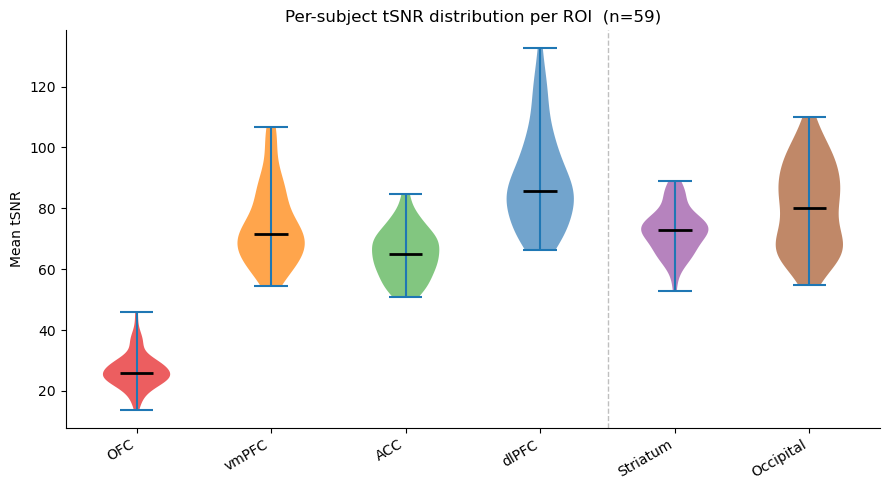

Subjects with mean tSNR < 30 in any PFC ROI:
subject roi      tsnr
 sub-19 OFC 13.823936
 sub-72 OFC 16.137690
 sub-15 OFC 17.063192
 sub-38 OFC 19.244728
 sub-50 OFC 19.268040
 sub-06 OFC 19.861571
 sub-59 OFC 20.766807
 sub-24 OFC 21.281114
 sub-33 OFC 21.762779
 sub-57 OFC 22.172479
 sub-54 OFC 22.387010
 sub-67 OFC 22.791701
 sub-49 OFC 23.138430
 sub-03 OFC 23.145822
 sub-10 OFC 23.185806
 sub-64 OFC 23.590986
 sub-40 OFC 23.631745
 sub-27 OFC 23.766548
 sub-53 OFC 24.223698
 sub-08 OFC 24.225234
 sub-56 OFC 24.313997
 sub-52 OFC 24.406536
 sub-18 OFC 24.632121
 sub-34 OFC 24.688305
 sub-55 OFC 24.761122
 sub-36 OFC 25.104564
 sub-29 OFC 25.391066
 sub-61 OFC 25.572470
 sub-71 OFC 25.843954
 sub-58 OFC 26.008353
 sub-01 OFC 26.049966
 sub-12 OFC 26.105433
 sub-21 OFC 26.365912
 sub-28 OFC 26.438628
 sub-05 OFC 26.565504
 sub-07 OFC 27.176271
 sub-35 OFC 27.280697
 sub-51 OFC 27.492135
 sub-02 OFC 28.088240
 sub-41 OFC 28.359001
 sub-26 OFC 28.956270
 sub-09 OFC 28.969299
 sub-73 O

In [4]:
sub_mean_paths = sorted(glob.glob(os.path.join(TSNR_DIR, "sub-*", "tsnr_mean.nii.gz")))
print(f"Found {len(sub_mean_paths)} subjects")

records = []
for path in sub_mean_paths:
    subject = os.path.basename(os.path.dirname(path))
    sub_data = nib.load(path).get_fdata()
    for name, roi_img in rois.items():
        roi_res = image.resample_to_img(roi_img, group_tsnr, interpolation='nearest')
        mask    = (roi_res.get_fdata() > 0) & (sub_data > 0)
        if mask.sum() == 0:
            continue
        records.append(dict(subject=subject, roi=name, tsnr=sub_data[mask].mean()))

df = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(9, 5))
roi_order_all = PFC_ROIS + REF_ROIS
data = [df[df['roi'] == r]['tsnr'].values for r in roi_order_all]

parts = ax.violinplot(data, positions=range(len(roi_order_all)),
                      showmedians=True, showextrema=True)
for pc, name in zip(parts['bodies'], roi_order_all):
    pc.set_facecolor(colors[name])
    pc.set_alpha(0.7)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

ax.axvline(len(PFC_ROIS) - 0.5, color='gray', lw=1, ls='--', alpha=0.5)
ax.set_xticks(range(len(roi_order_all)))
ax.set_xticklabels(roi_order_all, rotation=30, ha='right')
ax.set_ylabel('Mean tSNR')
ax.set_title(f'Per-subject tSNR distribution per ROI  (n={len(sub_mean_paths)})')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("Subjects with mean tSNR < 30 in any PFC ROI:")
low = df[df['roi'].isin(PFC_ROIS) & (df['tsnr'] < 30)][['subject', 'roi', 'tsnr']].sort_values('tsnr')
print(low.to_string(index=False) if len(low) else "  None")


## Conclusions

| ROI | Group mean tSNR | Interpretation |
|---|---|---|
| OFC | 26.1 | Severe dropout — 48/59 subjects below tSNR 30; voxels excluded from GLM mask |
| vmPFC | 74.4 | Good signal. SVC did not survive → effect is absent, not noise-limited |
| ACC | 65.2 | Good signal. No Q/H-value modulation detected |
| dlPFC | 88.8 | Good signal. Weak subthreshold Q-value trend only |
| Striatum | 72.7 | Good signal. Strongest Q-value effects in the dataset |
| Occipital | 80.1 | Good signal. Anomalously large negative H-value effect — possible confound |

**OFC** is an acquisition limitation (susceptibility dropout from orbital sinuses). No analysis-side fix is possible without a different sequence.

**vmPFC** tSNR = 74.4 (whole-brain mean = 62.3): signal quality rules out noise as an explanation for the null SVC result. The Q-value effect in vmPFC is genuinely small or absent at the group level.

**H-value showing negative effects across all PFC regions** (vmPFC, ACC, dlPFC) with adequate signal warrants further investigation — potential Q/H collinearity or genuine suppression.
